# Three-Variable Keller-Segel Slime Mold Chemotaxis Simulation

Simulating *Dictyostelium* chemotaxis with separate **self-produced chemoattractant** (cAMP) and **external nutrient** using a three-variable Keller-Segel model solved on a 2D finite-volume grid.

**Computational backend:** C++ (Eigen SparseLU + Scharfetter-Gummel scheme, via pybind11) when available; falls back to FiPy automatically.

**Three Coupled PDEs:**
- Cell density: $\partial\rho/\partial t = D_\rho \nabla^2\rho - \chi \nabla\cdot(\rho \nabla c) + \frac{\mu_{\max}}{Y} s \, \rho (1 - \rho/\rho_{\max})$
- cAMP chemoattractant (quasi-steady-state): $0 = D_c \nabla^2 c - \beta c + \alpha \rho$
- Nutrient/substrate (quasi-steady-state): $0 = D_s \nabla^2 s - \mu_{\max} s \, \rho$

**Key biological separation:**
- **cAMP (c)**: self-produced by cells (rate α), no-flux BCs — drives chemotactic aggregation via positive feedback
- **Nutrient (s)**: externally supplied at boundaries (Dirichlet BCs), consumed by cells — drives growth

In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

from keller_segel import DimensionalParams, KellerSegelParams, run_simulation, _HAS_CPP

backend = "C++ (Eigen SparseLU)" if _HAS_CPP else "FiPy"
print(f"Solver backend : {backend}")

Solver backend : C++ (Eigen SparseLU)


## Parameter Configuration

Parameters are set via `DimensionalParams` in physical units and converted to the dimensionless form used by the FiPy solver via `.to_dimensionless()`.

**Non-dimensionalization reference scales** (cAMP equation fixes all scales):

| Scale | Formula | Value |
|-------|---------|-------|
| Length L₀ | √(D_c / β) | 0.219 mm |
| Time T₀ | 1 / β | 2 min |
| cAMP c₀ | c_ref | 10 nM |
| Cell density ρ₀ | ρ_max | 10⁴ cells/mm² |
| Nutrient s₀ | s_boundary | 2 µg/mL |

**Physical parameters and resulting dimensionless solver values:**

| Parameter | Physical value | Units | Code value | Source |
|-----------|---------------|-------|-----------|--------|
| `D_c` | 0.024 | mm²/min (= 400 µm²/s) | 1.0 (reference) | Tomchik & Devreotes 1981 |
| `beta` | 0.5 | min⁻¹ | 1.0 (reference) | Martiel & Goldbeter 1987 |
| `alpha` | derived | nM·mm²/(cell·min) | 1.0 (derived) | c_ref · β / ρ_max |
| `D_rho` | 5×10⁻⁵ | mm²/min (= 50 µm²/min) | 0.0021 | Devreotes & Zigmond 1988 |
| `chi` | 1.8×10⁻³ | mm²/(nM·min) | 0.75 | Van Haastert & Veltman 2007 |
| `D_s` | 0.012 | mm²/min (= 200 µm²/s) | 0.5 | small-molecule diffusion |
| `mu_max` | 0.002 | min⁻¹ (≈ 5.8 hr doubling) | 0.004 | AX2 on bacteria |
| `K_s` | 0.5 | µg/mL | Y = 0.25 | Monod half-saturation |
| `rho_max` | 10⁴ | cells/mm² | 1.0 (reference) | close-packed monolayer |
| `s_boundary` | 2.0 | µg/mL | 1.0 (reference) | Dirichlet BC |

Two presets are available:
- `DimensionalParams.aggregation_phase()` — starved cells, χ = 1.8×10⁻³, no nutrient, 2 hr
- `DimensionalParams.growth_phase()` — dividing cells, χ = 1.8×10⁻⁴ (10× weaker), 10 hr

In [ ]:
# ── Phase selector ──────────────────────────────────────────────────────────
# Change PHASE to switch between presets:
#   "aggregation" — starved cells, strong χ, no nutrient, 2 hr
#   "growth"      — dividing cells, weak χ, full nutrient, 10 hr
#   "custom"      — edit DimensionalParams() kwargs below
PHASE = "growth"

if PHASE == "aggregation":
    dim = DimensionalParams.aggregation_phase()
elif PHASE == "growth":
    dim = DimensionalParams.growth_phase()
else:  # custom
    dim = DimensionalParams(
        chi_mm2_per_nM_per_min=1.8e-3,
        total_time_min=120.0,
        nx=100, ny=100,
    )

params = dim.to_dimensionless()

print(f"=== Dimensional parameters ({PHASE}) ===")
print(f"L₀             : {dim.L0_mm:.4f} mm  (cAMP decay length)")
print(f"T₀             : {dim.T0_min:.2f} min  (cAMP degradation time)")
print(f"α (derived)    : {dim.alpha_nM_mm2_per_cell_per_min:.2e} nM·mm²/(cell·min)")
print(f"Domain         : {dim.Lx_mm} × {dim.Ly_mm} mm  ({params.nx}×{params.ny} cells)")
print(f"Cell size (dx) : {dim.Lx_mm / params.nx * 1000:.0f} µm")
print(f"Physical time  : {dim.total_time_min:.0f} min  →  {params.n_steps} steps")
print()
print(f"=== Dimensionless solver parameters ===")
print(f"D_rho  = {params.D_rho:.5f}   chi    = {params.chi:.5f}")
print(f"D_s    = {params.D_s:.4f}    mu_max = {params.mu_max:.5f}")
print(f"Y      = {params.Y:.4f}    rho_max= {params.rho_max}")
print(f"Lx/Ly  = {params.Lx:.2f}     dt     = {params.dt:.5f}")
print(f"chi/D_rho = {params.chi / params.D_rho:.1f}  (chemotaxis vs. diffusion)")

=== Dimensional parameters (aggregation) ===
L₀             : 0.2191 mm  (cAMP decay length)
T₀             : 2.00 min  (cAMP degradation time)
α (derived)    : 5.00e-04 nM·mm²/(cell·min)
Domain         : 5.0 × 5.0 mm  (100×100 cells)
Cell size (dx) : 50 µm
Physical time  : 120 min  →  3000 steps

=== Dimensionless solver parameters ===
D_rho  = 0.00208   chi    = 0.75000
D_s    = 0.5000    mu_max = 0.00000
Y      = 1.0000    rho_max= 1.0
Lx/Ly  = 22.82     dt     = 0.02000
chi/D_rho = 360.0  (chemotaxis vs. diffusion)


## Run Simulation

In [3]:
t0 = time.perf_counter()
result = run_simulation(params)   # progbar ignored by C++ backend
elapsed = time.perf_counter() - t0

print(f"Backend        : {backend}")
print(f"Wall time      : {elapsed:.2f} s")
print(f"Snapshots      : {len(result.times)}")
print(f"Final total mass   : {result.total_mass[-1]:.4f}")
print(f"Final max density  : {result.max_density[-1]:.4f}")

Backend        : C++ (Eigen SparseLU)
Wall time      : 226.14 s
Snapshots      : 61
Final total mass   : 53.1305
Final max density  : 0.1198


## Static Snapshots

Cell density (top, inferno), cAMP chemoattractant (middle, plasma), and nutrient concentration (bottom, viridis) at three timepoints.

/var/folders/sp/mfjhmc0519351v_br7ctfm7c0000gn/T/ipykernel_31087/3510768880.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


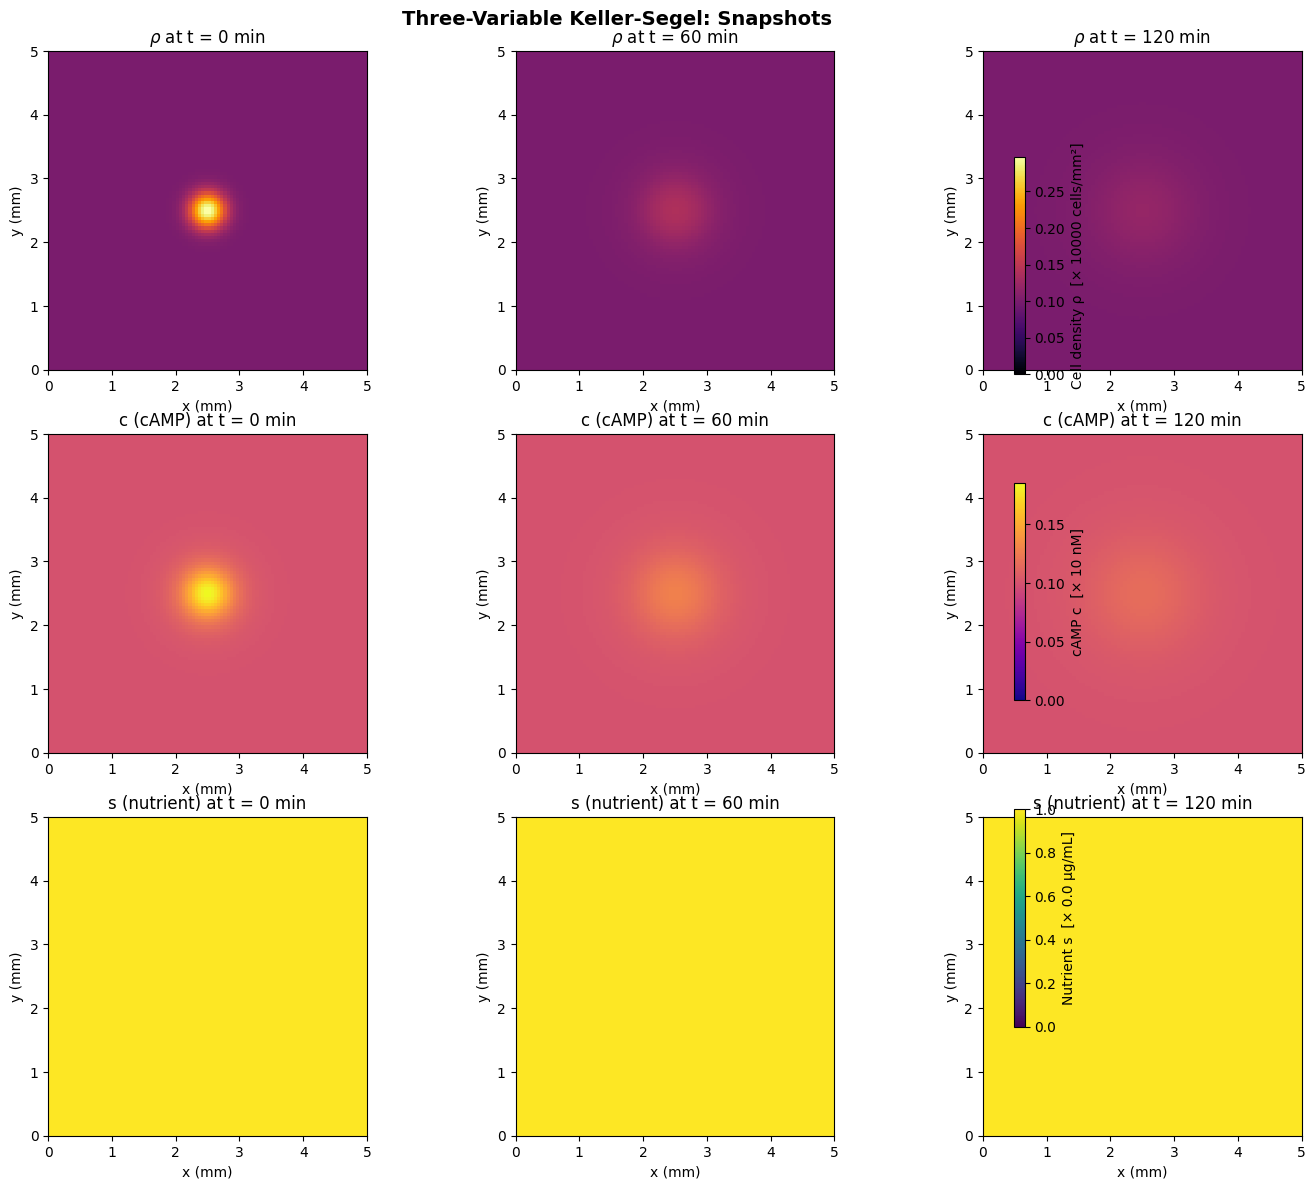

In [4]:
n_snapshots = len(result.times)
indices = [0, n_snapshots // 2, n_snapshots - 1]

fig, axes = plt.subplots(3, 3, figsize=(14, 12))

rho_vmax = max(snap.max() for snap in result.rho_snapshots)
c_vmax   = max(snap.max() for snap in result.c_snapshots)
s_vmax   = max(snap.max() for snap in result.s_snapshots)

extent_mm = [0, dim.Lx_mm, 0, dim.Ly_mm]

for col, idx in enumerate(indices):
    t_min = result.times[idx] * dim.T0_min  # convert code units → minutes

    im_rho = axes[0, col].imshow(
        result.rho_snapshots[idx], origin="lower", extent=extent_mm,
        cmap="inferno", vmin=0, vmax=rho_vmax,
    )
    axes[0, col].set_title(f"$\\rho$ at t = {t_min:.0f} min")
    axes[0, col].set_xlabel("x (mm)")
    axes[0, col].set_ylabel("y (mm)")

    im_c = axes[1, col].imshow(
        result.c_snapshots[idx], origin="lower", extent=extent_mm,
        cmap="plasma", vmin=0, vmax=c_vmax,
    )
    axes[1, col].set_title(f"c (cAMP) at t = {t_min:.0f} min")
    axes[1, col].set_xlabel("x (mm)")
    axes[1, col].set_ylabel("y (mm)")

    im_s = axes[2, col].imshow(
        result.s_snapshots[idx], origin="lower", extent=extent_mm,
        cmap="viridis", vmin=0, vmax=s_vmax,
    )
    axes[2, col].set_title(f"s (nutrient) at t = {t_min:.0f} min")
    axes[2, col].set_xlabel("x (mm)")
    axes[2, col].set_ylabel("y (mm)")

fig.colorbar(im_rho, ax=axes[0, :], label=f"Cell density ρ  [× {dim.rho_max_cells_per_mm2:.0f} cells/mm²]", shrink=0.8)
fig.colorbar(im_c,   ax=axes[1, :], label=f"cAMP c  [× {dim.c_ref_nM:.0f} nM]", shrink=0.8)
fig.colorbar(im_s,   ax=axes[2, :], label=f"Nutrient s  [× {dim.s_boundary_ug_per_mL:.1f} µg/mL]", shrink=0.8)
fig.suptitle("Three-Variable Keller-Segel: Snapshots", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("snapshots.png", dpi=150, bbox_inches="tight")
plt.show()

## Diagnostics: Total Mass and Max Density

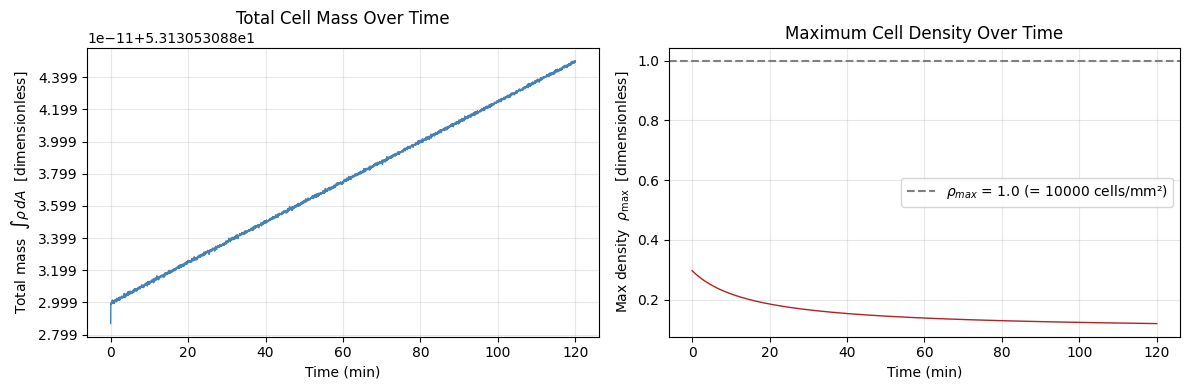

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# total_mass / max_density are recorded once per step (+ initial), so n_steps+1 entries.
# Convert to physical time in minutes.
n_diag = len(result.total_mass)
t_min_diag = np.linspace(0, dim.total_time_min, n_diag)

ax1.plot(t_min_diag, result.total_mass, color="steelblue", linewidth=1)
ax1.set_xlabel("Time (min)")
ax1.set_ylabel("Total mass  $\\int \\rho\\, dA$  [dimensionless]")
ax1.set_title("Total Cell Mass Over Time")
ax1.grid(True, alpha=0.3)

ax2.plot(t_min_diag, result.max_density, color="firebrick", linewidth=1)
ax2.axhline(y=params.rho_max, color="gray", linestyle="--",
            label=f"$\\rho_{{max}}$ = {params.rho_max} (= {dim.rho_max_cells_per_mm2:.0f} cells/mm²)")
ax2.set_xlabel("Time (min)")
ax2.set_ylabel("Max density  $\\rho_\\mathrm{max}$  [dimensionless]")
ax2.set_title("Maximum Cell Density Over Time")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

## Animation: Cell Density, cAMP, and Nutrient

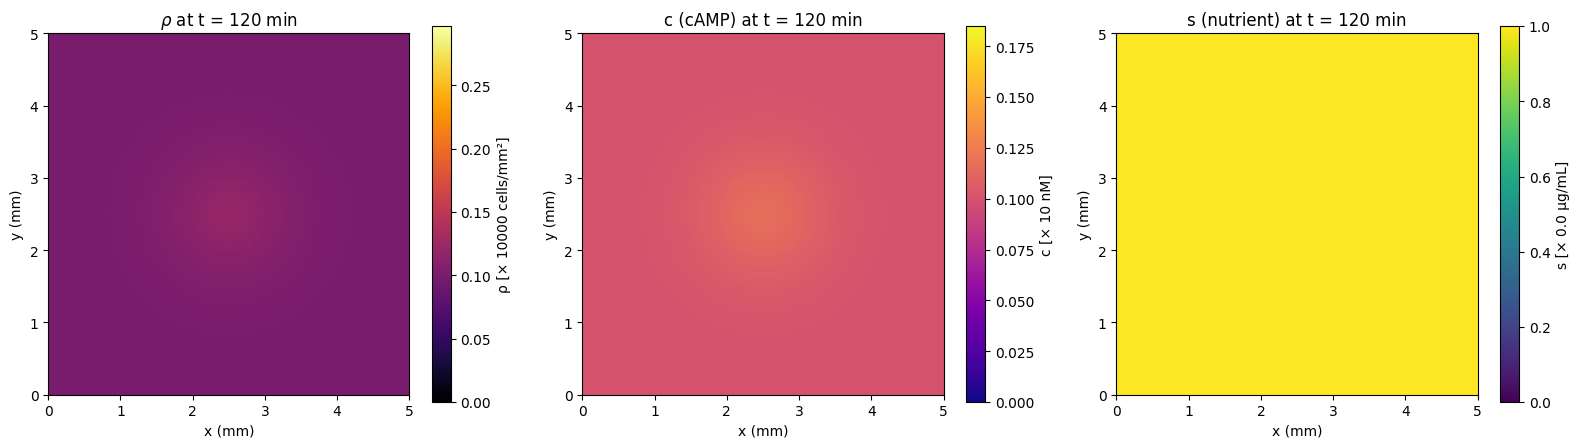

In [6]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))

rho_vmax = max(snap.max() for snap in result.rho_snapshots)
c_vmax   = max(snap.max() for snap in result.c_snapshots)
s_vmax   = max(snap.max() for snap in result.s_snapshots)

extent_mm = [0, dim.Lx_mm, 0, dim.Ly_mm]

im1 = ax1.imshow(
    result.rho_snapshots[0], origin="lower", extent=extent_mm,
    cmap="inferno", vmin=0, vmax=rho_vmax,
)
ax1.set_title("$\\rho$ at t = 0 min")
ax1.set_xlabel("x (mm)")
ax1.set_ylabel("y (mm)")
fig.colorbar(im1, ax=ax1, label=f"ρ [× {dim.rho_max_cells_per_mm2:.0f} cells/mm²]", shrink=0.8)

im2 = ax2.imshow(
    result.c_snapshots[0], origin="lower", extent=extent_mm,
    cmap="plasma", vmin=0, vmax=c_vmax,
)
ax2.set_title("c (cAMP) at t = 0 min")
ax2.set_xlabel("x (mm)")
ax2.set_ylabel("y (mm)")
fig.colorbar(im2, ax=ax2, label=f"c [× {dim.c_ref_nM:.0f} nM]", shrink=0.8)

im3 = ax3.imshow(
    result.s_snapshots[0], origin="lower", extent=extent_mm,
    cmap="viridis", vmin=0, vmax=s_vmax,
)
ax3.set_title("s (nutrient) at t = 0 min")
ax3.set_xlabel("x (mm)")
ax3.set_ylabel("y (mm)")
fig.colorbar(im3, ax=ax3, label=f"s [× {dim.s_boundary_ug_per_mL:.1f} µg/mL]", shrink=0.8)

plt.tight_layout()


def animate(frame):
    t_min = result.times[frame] * dim.T0_min
    im1.set_data(result.rho_snapshots[frame])
    im2.set_data(result.c_snapshots[frame])
    im3.set_data(result.s_snapshots[frame])
    ax1.set_title(f"$\\rho$ at t = {t_min:.0f} min")
    ax2.set_title(f"c (cAMP) at t = {t_min:.0f} min")
    ax3.set_title(f"s (nutrient) at t = {t_min:.0f} min")
    return [im1, im2, im3]


anim = animation.FuncAnimation(
    fig, animate,
    frames=len(result.times),
    interval=200,
    blit=True,
)

HTML(anim.to_html5_video())

## Analysis

### Self-Organized Aggregation via cAMP Positive Feedback
The three-variable model captures the core *Dictyostelium* aggregation mechanism: cells **produce** cAMP (at rate α), which diffuses locally and is degraded by phosphodiesterase (rate β). Where cells cluster, cAMP concentration rises, creating a gradient that attracts more cells via chemotaxis (χ∇c). This positive feedback loop drives self-organized aggregation — cells move toward each other, not toward boundaries.

### Nutrient Depletion as Growth Limiter
Nutrient (s) is supplied at the domain boundaries (Dirichlet BCs) and consumed by cells at rate μ_max·s·ρ. Where cells are dense, nutrient is depleted locally, reducing the growth rate. This creates a natural growth ceiling: total mass increases initially but plateaus as nutrient limitation kicks in. The logistic cap (1 - ρ/ρ_max) provides an additional safety bound.

### Separation of Chemotaxis and Growth Roles
Unlike the previous two-variable model where cells consumed the same signal they were chasing (destroying the gradient driving movement), here:
- **cAMP (c)** drives chemotaxis only — self-produced, no-flux BCs, not consumed
- **Nutrient (s)** drives growth only — externally supplied, Dirichlet BCs, consumed by cells

This separation is biologically correct: in real *Dictyostelium*, cAMP is a self-produced signaling molecule while nutrients (bacteria, folate) are separate external substrates.

### Tokyo Metro Connection
The model is now architecturally ready for the Physarum/Tokyo Metro experiment: food sources can be placed at specific boundary locations via the per-edge `s_boundary` dict (e.g., `{"left": 1.0, "right": 1.0, "top": 0.0, "bottom": 0.0}`), and cells will self-organize transport paths between them via cAMP-mediated aggregation — analogous to how *Physarum* forms efficient networks between food sources.

### Conservation and Stability
- **Total mass** is not conserved (growth term adds biomass) but is self-limiting via nutrient depletion and logistic saturation
- **cAMP field** peaks where cells cluster (self-produced) — opposite of the old model where it was depleted by cells
- **Nutrient field** shows depletion where cells are dense (consumed) — supplied from boundaries
- The `ExponentialConvectionTerm` (Scharfetter-Gummel scheme) remains critical for stability when the Peclet number Pe = χ|∇c|Δx/D_ρ is large